# Quasi3D electric-field plotting

This notebook uses `include.simulations.useQuasi3D` directly, instead of loading precomputed `Er-plot-data.npz` and `Ez-plot-data.npz` files.

In [19]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as col

plt.rcParams.update({"font.size": 12})

import include.simulations.useQuasi3D as sim

In [20]:
# Choose the same input *module* you use with main.py, without ".py".
# Example: python main.py betatron_tutorial_input

# input_module = "input.betatron_tutorial_input"
input_module = "input.ATF_1D_lens"

init = importlib.import_module(input_module)
sim.configure(init)

print("Loaded Quasi3D ID:", init.quasi_id)
print("t0 =", sim.getTime())
print("dt =", sim.getDt())
print("bounds =", sim.getBoundCond())

Loaded Quasi3D ID: 000130
t0 = 51.9948
dt = 0.00044588006817010824
bounds = [np.float64(-25.010229828385715), np.float64(-0.01022982838571096), np.float64(2.85364)]


In [21]:
def add_z_axis(ax):
    """Add a top z-axis corresponding to the bottom xi-axis."""
    t0 = sim.getTime()
    vg = sim.getPropagationSpeed()

    def xi_to_z(xi):
        return xi + t0 * vg

    def z_to_xi(z):
        return z - t0 * vg

    secax = ax.secondary_xaxis("top", functions=(xi_to_z, z_to_xi))
    secax.set_xlabel(r"$z$ $(c/\omega_p)$")
    return secax


def plot_field(ax, xaxis, raxis, field, title, *, cmap="RdBu_r",
               linthresh=0.03, vmin=None, vmax=None, ylim=None):
    """Plot a 2D field array Field[r, xi]."""
    norm = col.SymLogNorm(linthresh=linthresh, vmin=vmin, vmax=vmax)
    mesh = ax.pcolormesh(xaxis, raxis, field, shading="auto", cmap=cmap, norm=norm)
    ax.set_title(title)
    ax.set_xlabel(r"$\xi$ $(c/\omega_p)$")
    ax.set_ylabel(r"$r$ $(c/\omega_p)$")
    if ylim is not None:
        ax.set_ylim(*ylim)
    add_z_axis(ax)
    return mesh

## Plot the transverse electric field

For `phi = 0`, the M0 radial field corresponds to the transverse x-field: `E_x = E_r = E2_M0`.

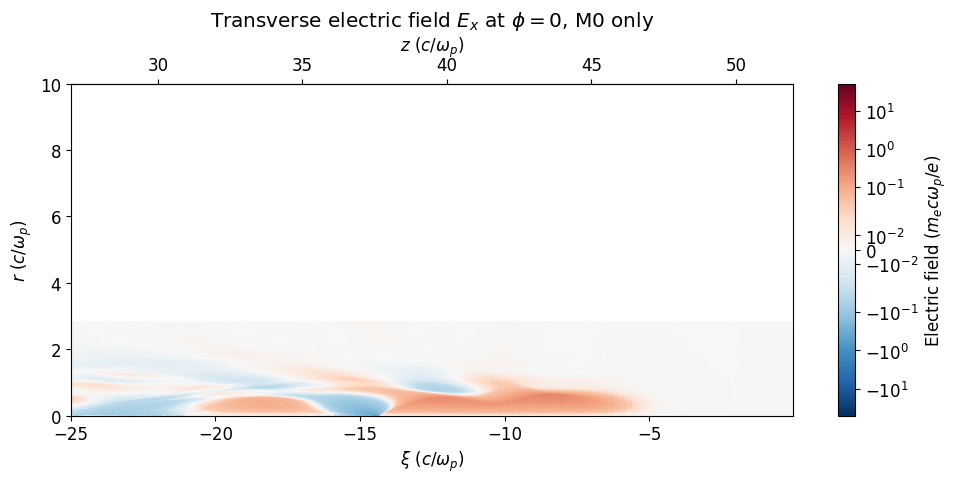

In [22]:
# M0 radial/transverse electric field at phi = 0:
# E_x(phi=0) = E_r,m0, so this is simply E2_M0.
fig, ax = plt.subplots(figsize=(10, 5))

mesh = plot_field(
    ax,
    sim.xiaxis_2,
    sim.raxis_1,
    sim.E2_M0,
    r"Transverse electric field $E_x$ at $\phi=0$, M0 only",
    vmin=-50,
    vmax=50,
    ylim=(0, 10),
)

cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label(r"Electric field $(m_e c \omega_p / e)$")

fig.tight_layout()
plt.show()

## Plot transverse and longitudinal electric fields

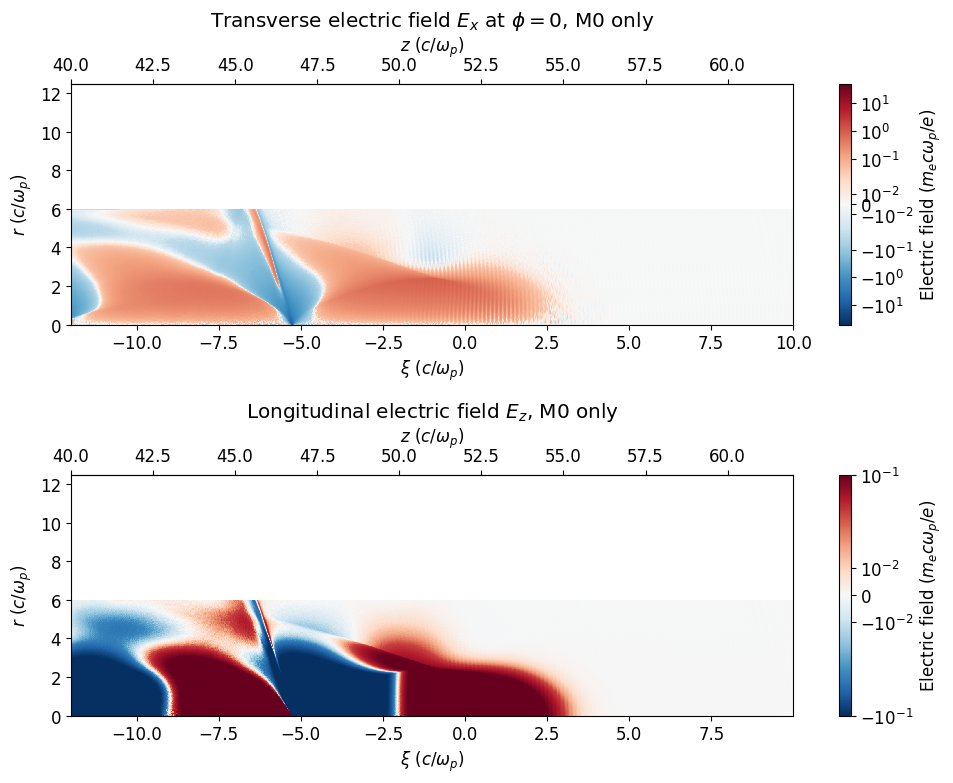

In [18]:
fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=False)

mesh0 = plot_field(
    axs[0],
    sim.xiaxis_2,
    sim.raxis_1,
    sim.E2_M0,
    r"Transverse electric field $E_x$ at $\phi=0$, M0 only",
    vmin=-50,
    vmax=50,
    ylim=(0, 12.5),
)

mesh1 = plot_field(
    axs[1],
    sim.xiaxis_1,
    sim.raxis_2,
    sim.E1_M0,
    r"Longitudinal electric field $E_z$, M0 only",
    vmin=-0.1,
    vmax=0.1,
    ylim=(0, 12.5),
)

cbar0 = fig.colorbar(mesh0, ax=axs[0])
cbar1 = fig.colorbar(mesh1, ax=axs[1])
cbar0.set_label(r"Electric field $(m_e c \omega_p / e)$")
cbar1.set_label(r"Electric field $(m_e c \omega_p / e)$")

fig.tight_layout()
plt.show()

### Plot Laser filed

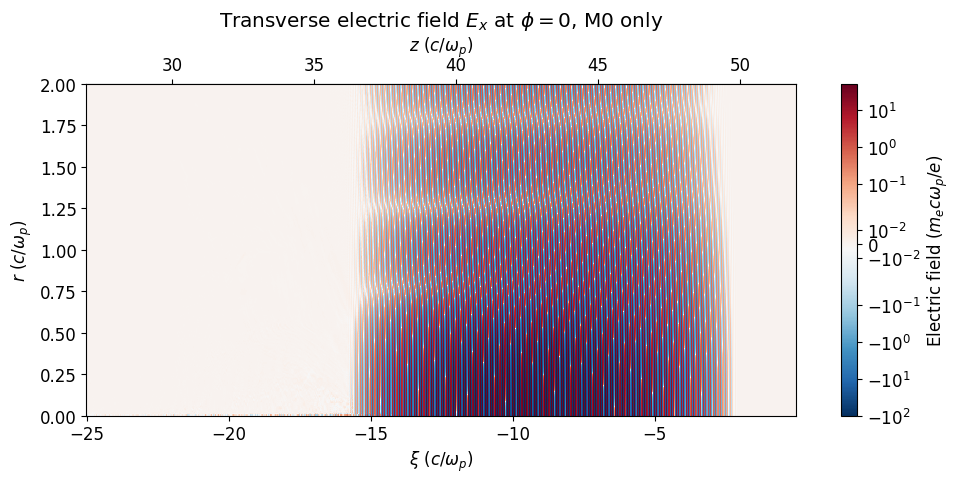

In [32]:
# Transverse/radial electric field with the debug trajectory overlaid.
# For mode 0 and phi = 0, E2_M0 corresponds to the radial/transverse field.
# E2_M0 lives on (xiaxis_2, raxis_1).
fig, ax = plt.subplots(figsize=(10, 5))

mesh = plot_field(
    ax,
    sim.xiaxis_2,
    sim.raxis_1,
    sim.E2_M1_Re,
    r"Transverse electric field $E_x$ at $\phi=0$, M0 only",
    vmin=-100,
    vmax=50,
    ylim=(0, 2),
)

# ax.set_xlim(-5,-1)

cbar = fig.colorbar(mesh, ax=ax)
cbar.set_label(r"Electric field $(m_e c \omega_p / e)$")

fig.tight_layout()
plt.show()

## Optional: inspect trajectory `.npz` output

In [7]:
# Optional: inspect a trajectory output file produced by main.py.
# This is different from the old Er-plot-data.npz / charge-plot-data.npz files.
trajectory_file = "data/betatron_tutorial_input.npz"

try:
    traj = np.load(trajectory_file)
    print("Keys:", traj.files)
    for key in traj.files:
        arr = traj[key]
        print(f"{key:8s}", arr.shape, arr.dtype)
except FileNotFoundError:
    print(f"Did not find {trajectory_file!r}. Update trajectory_file if needed.")

Keys: ['x_init', 'y_init', 'xi_init', 'z_init', 'x_dat', 'y_dat', 'xi_dat', 'z_dat', 'px_dat', 'py_dat', 'pz_dat', 't_dat']
x_init   (1,) int64
y_init   (1,) float64
xi_init  (1,) float64
z_init   (1,) float64
x_dat    (1,) float64
y_dat    (1,) float64
xi_dat   (1,) float64
z_dat    (1,) float64
px_dat   (1,) float64
py_dat   (1,) float64
pz_dat   (1,) float64
t_dat    () float64
